In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [5]:
from google.colab import files

uploaded = files.upload()
FILE_PATH = "EduPro Online Platform.xlsx"

Saving EduPro Online Platform.xlsx to EduPro Online Platform (1).xlsx


In [6]:
users = pd.read_excel(FILE_PATH, sheet_name="Users")
teachers = pd.read_excel(FILE_PATH, sheet_name="Teachers")
courses = pd.read_excel(FILE_PATH, sheet_name="Courses")
transactions = pd.read_excel(FILE_PATH, sheet_name="Transactions")

print("Users:", users.shape)
print("Teachers:", teachers.shape)
print("Courses:", courses.shape)
print("Transactions:", transactions.shape)

Users: (3000, 5)
Teachers: (60, 7)
Courses: (60, 8)
Transactions: (10000, 7)


In [7]:
display(users.head())
display(teachers.head())
display(courses.head())
display(transactions.head())

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [8]:
print("Users missing values")
print(users.isnull().sum())

print("\nTeachers missing values")
print(teachers.isnull().sum())

print("\nCourses missing values")
print(courses.isnull().sum())

print("\nTransactions missing values")
print(transactions.isnull().sum())

Users missing values
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Teachers missing values
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Courses missing values
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions missing values
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [9]:
print("Transaction date range:")
print(transactions["TransactionDate"].min())
print(transactions["TransactionDate"].max())

print("\nCourse categories:")
print(courses["CourseCategory"].value_counts())

print("\nCourse levels:")
print(courses["CourseLevel"].value_counts())

print("\nCourse types:")
print(courses["CourseType"].value_counts())

Transaction date range:
2025-01-01 00:00:00
2025-12-30 00:00:00

Course categories:
CourseCategory
Programming                5
Design                     5
Business                   5
Marketing                  5
Data Science               5
Machine Learning           5
Cybersecurity              5
Project Management         5
Finance                    5
Artificial Intelligence    5
Web Development            5
Digital Marketing          5
Name: count, dtype: int64

Course levels:
CourseLevel
Beginner        21
Advanced        21
Intermediate    18
Name: count, dtype: int64

Course types:
CourseType
Free    38
Paid    22
Name: count, dtype: int64


In [10]:
transactions["TransactionDate"] = pd.to_datetime(
    transactions["TransactionDate"]
)

transactions["Month"] = transactions["TransactionDate"].dt.month
transactions["MonthName"] = transactions["TransactionDate"].dt.month_name()

In [11]:
merged = transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

merged = merged.merge(
    teachers,
    on="TeacherID",
    how="left"
)

print(merged.shape)

display(merged.head())

(10000, 22)


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,Month,MonthName,CourseName,...,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,10,October,Digital Marketing,...,Intermediate,0.0,42.68,4.72,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,1,January,Scrum Essentials,...,Intermediate,0.0,33.93,3.45,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,3,March,Content Marketing,...,Advanced,0.0,18.00,2.98,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,6,June,AI Ethics,...,Beginner,0.0,42.70,3.64,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,8,August,Content Creation,...,Beginner,0.0,8.95,2.14,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [12]:
cutoff_date = pd.Timestamp("2025-10-01")

historical = merged[
    merged["TransactionDate"] < cutoff_date
].copy()

future = merged[
    merged["TransactionDate"] >= cutoff_date
].copy()

print("Historical records:", historical.shape)
print("Future records:", future.shape)

Historical records: (7551, 22)
Future records: (2449, 22)


In [13]:
historical_features = (
    historical
    .groupby("CourseID")
    .agg(
        PastEnrollments=("TransactionID", "count"),
        PastRevenue=("Amount", "sum"),
        PastAverageRevenue=("Amount", "mean"),
        PastRevenueStd=("Amount", "std"),
        UniqueUsers=("UserID", "nunique")
    )
    .reset_index()
)

historical_features.head()

,CourseID,PastEnrollments,PastRevenue,PastAverageRevenue,PastRevenueStd,UniqueUsers
0,CR00001,126,59507.28,472.28,0.0,126
1,CR00002,116,0.00,0.00,0.0,116
2,CR00003,122,0.00,0.00,0.0,122
3,CR00004,116,0.00,0.00,0.0,116
4,CR00005,129,0.00,0.00,0.0,129


In [14]:
future_targets = (
    future
    .groupby("CourseID")
    .agg(
        FutureEnrollments=("TransactionID", "count"),
        FutureRevenue=("Amount", "sum")
    )
    .reset_index()
)

future_targets.head()

,CourseID,FutureEnrollments,FutureRevenue
0,CR00001,38,17946.64
1,CR00002,33,0.00
2,CR00003,51,0.00
3,CR00004,38,0.00
4,CR00005,37,0.00


In [15]:
model_data = courses.copy()

In [16]:
course_teacher = (
    transactions
    .groupby("CourseID")["TeacherID"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

course_teacher.head()

,CourseID,TeacherID
0,CR00001,TC00042
1,CR00002,TC00042
2,CR00003,TC00040
3,CR00004,TC00040
4,CR00005,TC00040


In [17]:
model_data = model_data.merge(
    course_teacher,
    on="CourseID",
    how="left"
)

In [18]:
model_data = model_data.merge(
    teachers,
    on="TeacherID",
    how="left"
)

In [19]:
model_data = model_data.merge(
    historical_features,
    on="CourseID",
    how="left"
)

model_data = model_data.merge(
    future_targets,
    on="CourseID",
    how="left"
)

print(model_data.shape)

display(model_data.head())

(60, 22)


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,...,Expertise,YearsOfExperience,TeacherRating,PastEnrollments,PastRevenue,PastAverageRevenue,PastRevenueStd,UniqueUsers,FutureEnrollments,FutureRevenue
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Yolanda Levine,...,Machine Learning,21,4.97,126,59507.28,472.28,0.0,126,38,17946.64
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,TC00042,Yolanda Levine,...,Machine Learning,21,4.97,116,0.00,0.00,0.0,116,33,0.00
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,TC00040,Kimberly Miller,...,Cybersecurity,24,4.58,122,0.00,0.00,0.0,122,51,0.00
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,TC00040,Kimberly Miller,...,Cybersecurity,24,4.58,116,0.00,0.00,0.0,116,38,0.00
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,TC00040,Kimberly Miller,...,Cybersecurity,24,4.58,129,0.00,0.00,0.0,129,37,0.00


In [20]:
historical_columns = [
    "PastEnrollments",
    "PastRevenue",
    "PastAverageRevenue",
    "PastRevenueStd",
    "UniqueUsers"
]

model_data[historical_columns] = (
    model_data[historical_columns]
    .fillna(0)
)

In [21]:
model_data["FutureEnrollments"] = (
    model_data["FutureEnrollments"]
    .fillna(0)
)

model_data["FutureRevenue"] = (
    model_data["FutureRevenue"]
    .fillna(0)
)

In [22]:
def price_band(price):
    if price == 0:
        return "Free"
    elif price <= 150:
        return "Low"
    elif price <= 300:
        return "Medium"
    else:
        return "High"

model_data["PriceBand"] = (
    model_data["CoursePrice"]
    .apply(price_band)
)

In [23]:
def duration_bucket(duration):

    if duration <= 10:
        return "Short"

    elif duration <= 25:
        return "Medium"

    else:
        return "Long"

model_data["DurationBucket"] = (
    model_data["CourseDuration"]
    .apply(duration_bucket)
)

In [24]:
def rating_tier(rating):

    if rating < 3:
        return "Low"

    elif rating < 4:
        return "Medium"

    else:
        return "High"

model_data["RatingTier"] = (
    model_data["CourseRating"]
    .apply(rating_tier)
)

In [25]:
def experience_bucket(years):

    if years <= 3:
        return "Junior"

    elif years <= 7:
        return "Mid"

    else:
        return "Senior"

model_data["ExperienceBucket"] = (
    model_data["YearsOfExperience"]
    .apply(experience_bucket)
)

In [26]:
def expertise_match(row):

    category = str(row["CourseCategory"]).lower()
    expertise = str(row["Expertise"]).lower()

    keywords = {
        "programming": ["programming", "software", "computer"],
        "data science": ["data", "analytics", "statistics"],
        "machine learning": ["machine", "learning", "ai"],
        "artificial intelligence": ["artificial", "intelligence", "ai"],
        "web development": ["web", "development"],
        "cybersecurity": ["security", "cyber"],
        "design": ["design", "ui", "ux"],
        "marketing": ["marketing"],
        "digital marketing": ["marketing", "digital"],
        "finance": ["finance", "accounting"],
        "business": ["business", "management"],
        "project management": ["management", "project"]
    }

    terms = keywords.get(category, [])

    return int(any(term in expertise for term in terms))

model_data["ExpertiseMatch"] = model_data.apply(
    expertise_match,
    axis=1
)

In [27]:
display(
    model_data[
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CoursePrice",
            "CourseDuration",
            "CourseRating",
            "YearsOfExperience",
            "TeacherRating",
            "PastEnrollments",
            "PastRevenue",
            "FutureEnrollments",
            "FutureRevenue"
        ]
    ].head(10)
)

,CourseID,CourseName,CourseCategory,CoursePrice,CourseDuration,CourseRating,YearsOfExperience,TeacherRating,PastEnrollments,PastRevenue,FutureEnrollments,FutureRevenue
0,CR00001,Python Basics,Programming,472.28,11.00,4.74,21,4.97,126,59507.28,38,17946.64
1,CR00002,Java Programming,Programming,0.00,37.70,2.43,21,4.97,116,0.00,33,0.00
2,CR00003,C++ for Beginners,Programming,0.00,19.53,3.85,24,4.58,122,0.00,51,0.00
3,CR00004,Advanced Python,Programming,0.00,45.13,2.88,24,4.58,116,0.00,38,0.00
4,CR00005,Full Stack Development,Programming,0.00,28.68,1.28,24,4.58,129,0.00,37,0.00
5,CR00006,Graphic Design Basics,Design,276.37,48.84,2.72,21,4.97,117,32335.29,39,10778.43
6,CR00007,UI/UX Design,Design,0.00,48.68,2.61,24,4.58,129,0.00,49,0.00
7,CR00008,Photoshop Mastery,Design,0.00,2.87,1.52,21,4.97,114,0.00,44,0.00
8,CR00009,Web Design Fundamentals,Design,0.00,48.19,4.51,21,4.97,121,0.00,34,0.00
9,CR00010,3D Modeling,Design,0.00,15.29,4.45,24,4.58,130,0.00,50,0.00


In [28]:
features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "Expertise",
    "YearsOfExperience",
    "TeacherRating",
    "PriceBand",
    "DurationBucket",
    "RatingTier",
    "ExperienceBucket",
    "ExpertiseMatch",
    "PastEnrollments",
    "PastRevenue",
    "PastAverageRevenue",
    "PastRevenueStd",
    "UniqueUsers"
]

In [29]:
X = model_data[features]

y_enrollment = model_data["FutureEnrollments"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enrollment,
    test_size=0.2,
    random_state=42
)

In [30]:
categorical_features = [
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "Expertise",
    "PriceBand",
    "DurationBucket",
    "RatingTier",
    "ExperienceBucket"
]

numerical_features = [
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "YearsOfExperience",
    "TeacherRating",
    "ExpertiseMatch",
    "PastEnrollments",
    "PastRevenue",
    "PastAverageRevenue",
    "PastRevenueStd",
    "UniqueUsers"
]

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

In [32]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'YearsOfExperience',
                                                   'TeacherRating',
                                                   'ExpertiseMatch',
                                                   'PastEnrollments',
                                                   'PastRevenue',
                                                   'PastAverageRevenue',
                                                   'PastRevenueStd',
                                                   'UniqueUsers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise', 'PriceBand',
                                                   'DurationBucket',
                                                   'RatingTier',
                                                   'ExperienceBucket'])])),
                ('model', LinearRegression())])

In [33]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'YearsOfExperience',
                                                   'TeacherRating',
                                                   'ExpertiseMatch',
                                                   'PastEnrollments',
                                                   'PastRevenue',
                                                   'PastAverageRevenue',
                                                   'PastRevenueStd',
                                                   'UniqueUsers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise', 'PriceBand',
                                                   'DurationBucket',
                                                   'RatingTier',
                                                   'ExperienceBucket'])])),
                ('model', Ridge())])

In [34]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_split=3,
            random_state=42
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'YearsOfExperience',
                                                   'TeacherRating',
                                                   'ExpertiseMatch',
                                                   'PastEnrollments',
                                                   'PastRevenue',
                                                   'PastAverageRevenue',
                                                   'PastRevenueStd',
                                                   'UniqueUsers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise', 'PriceBand',
                                                   'DurationBucket',
                                                   'RatingTier',
                                                   'ExperienceBucket'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_split=3,
                                       n_estimators=300, random_state=42))])

In [35]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

gb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'YearsOfExperience',
                                                   'TeacherRating',
                                                   'ExpertiseMatch',
                                                   'PastEnrollments',
                                                   'PastRevenue',
                                                   'PastAverageRevenue',
                                                   'PastRevenueStd',
                                                   'UniqueUsers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise', 'PriceBand',
                                                   'DurationBucket',
                                                   'RatingTier',
                                                   'ExperienceBucket'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [36]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [37]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,

    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    results.append({
        "Model": name,
        **metrics
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
2,Random Forest,6.413880,7.862295,-0.425830
3,Gradient Boosting,6.993108,8.054796,-0.496505
1,Ridge Regression,7.444559,8.790036,-0.782176
0,Linear Regression,10.289905,11.454849,-2.026550


In [38]:
best_enrollment_name = (
    results_df
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

best_enrollment_model = models[
    best_enrollment_name
]

print(
    "Best Enrollment Model:",
    best_enrollment_name
)

Best Enrollment Model: Random Forest


In [39]:
y_revenue = model_data["FutureRevenue"]

In [40]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_revenue,
    test_size=0.2,
    random_state=42
)

In [41]:
revenue_models = {

    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                random_state=42
            )
        )
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ])
}

In [42]:
for name, model in revenue_models.items():

    model.fit(
        X_train_r,
        y_train_r
    )

In [43]:
revenue_results = []

for name, model in revenue_models.items():

    metrics = evaluate_model(
        model,
        X_test_r,
        y_test_r
    )

    revenue_results.append({
        "Model": name,
        **metrics
    })

revenue_results_df = pd.DataFrame(
    revenue_results
)

revenue_results_df.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
1,Ridge Regression,839.636105,1299.659117,0.968252
0,Linear Regression,973.481326,1411.104741,0.962574
2,Random Forest,942.677378,1577.239602,0.953242
3,Gradient Boosting,1371.782098,2265.110136,0.903564


In [44]:
best_revenue_name = (
    revenue_results_df
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

best_revenue_model = revenue_models[
    best_revenue_name
]

print(
    "Best Revenue Model:",
    best_revenue_name
)

Best Revenue Model: Ridge Regression


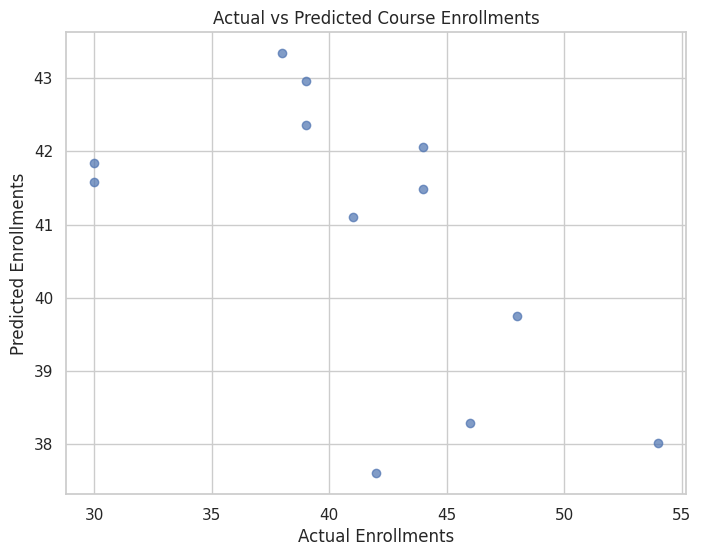

In [45]:
enrollment_predictions = (
    best_enrollment_model.predict(X_test)
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    enrollment_predictions,
    alpha=0.7
)

plt.xlabel("Actual Enrollments")
plt.ylabel("Predicted Enrollments")

plt.title(
    "Actual vs Predicted Course Enrollments"
)

plt.show()

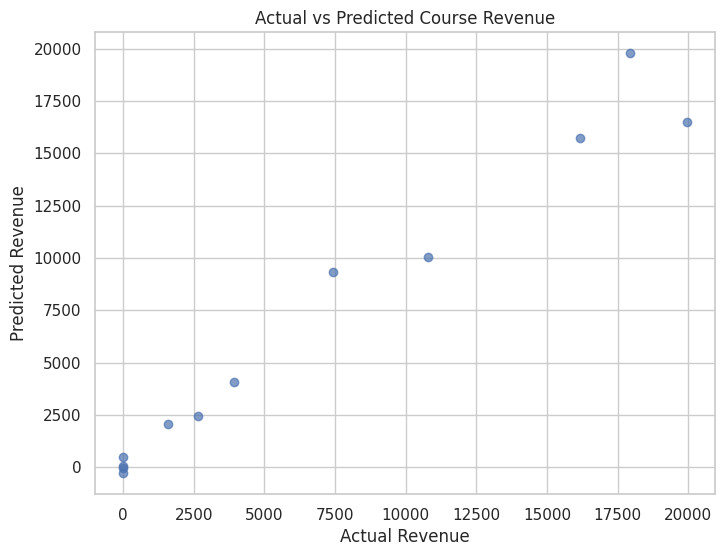

In [46]:
revenue_predictions = (
    best_revenue_model.predict(X_test_r)
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_r,
    revenue_predictions,
    alpha=0.7
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    "Actual vs Predicted Course Revenue"
)

plt.show()


In [47]:
importance_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=500,
            random_state=42
        )
    )
])

importance_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CoursePrice',
                                                   'CourseDuration',
                                                   'CourseRating',
                                                   'YearsOfExperience',
                                                   'TeacherRating',
                                                   'ExpertiseMatch',
                                                   'PastEnrollments',
                                                   'PastRevenue',
                                                   'PastAverageRevenue',
                                                   'PastRevenueStd',
                                                   'UniqueUsers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CourseCategory',
                                                   'CourseType', 'CourseLevel',
                                                   'Expertise', 'PriceBand',
                                                   'DurationBucket',
                                                   'RatingTier',
                                                   'ExperienceBucket'])])),
                ('model',
                 RandomForestRegressor(n_estimators=500, random_state=42))])

In [48]:
feature_names = (
    importance_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    importance_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
1,num__CourseDuration,0.250307
2,num__CourseRating,0.151480
16,cat__CourseCategory_Digital Marketing,0.097279
10,num__UniqueUsers,0.071425
6,num__PastEnrollments,0.066773
18,cat__CourseCategory_Machine Learning,0.049820
26,cat__CourseLevel_Beginner,0.035150
22,cat__CourseCategory_Web Development,0.030215
20,cat__CourseCategory_Programming,0.026830
27,cat__CourseLevel_Intermediate,0.026255


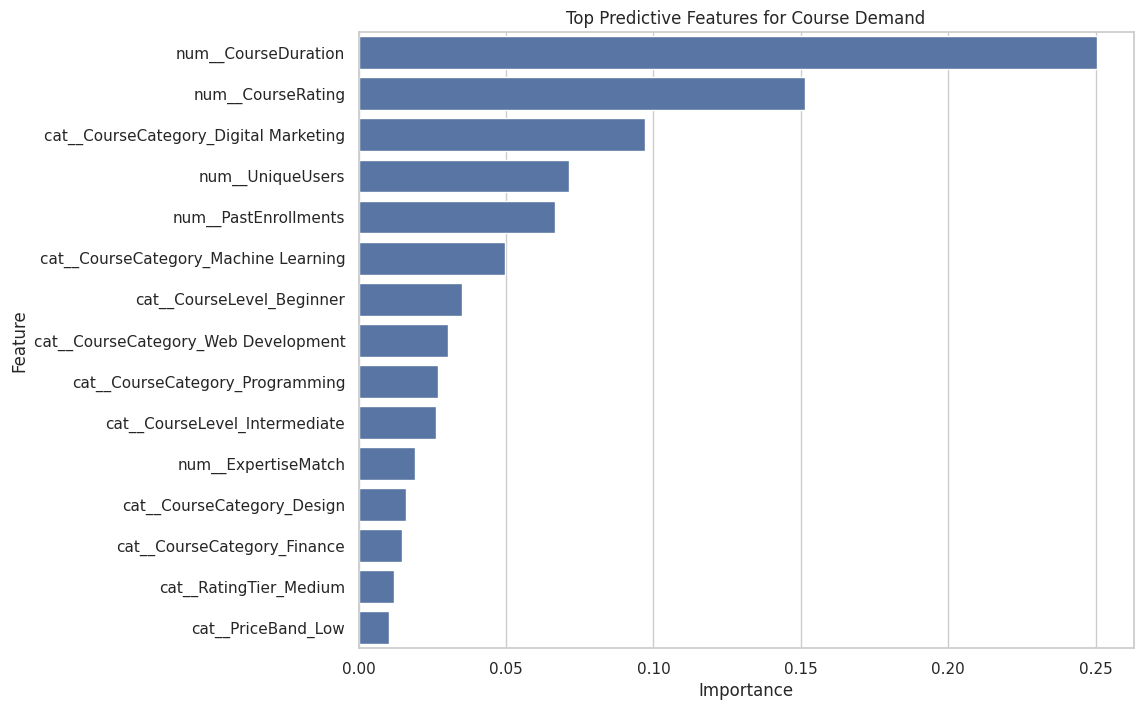

In [49]:
plt.figure(figsize=(10,8))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictive Features for Course Demand"
)

plt.show()

In [50]:
category_analysis = (
    merged
    .groupby("CourseCategory")
    .agg(
        Enrollments=("TransactionID", "count"),
        Revenue=("Amount", "sum"),
        AverageRevenue=("Amount", "mean")
    )
    .reset_index()
)

category_analysis

,CourseCategory,Enrollments,Revenue,AverageRevenue
0,Artificial Intelligence,829,202750.67,244.572581
1,Business,833,181527.58,217.920264
2,Cybersecurity,819,59139.00,72.208791
3,Data Science,916,77052.32,84.118253
4,Design,827,43113.72,52.132672
5,Digital Marketing,808,56261.32,69.630347
6,Finance,864,28106.20,32.530324
7,Machine Learning,819,133.38,0.162857
8,Marketing,806,0.00,0.000000
9,Programming,806,77453.92,96.096675


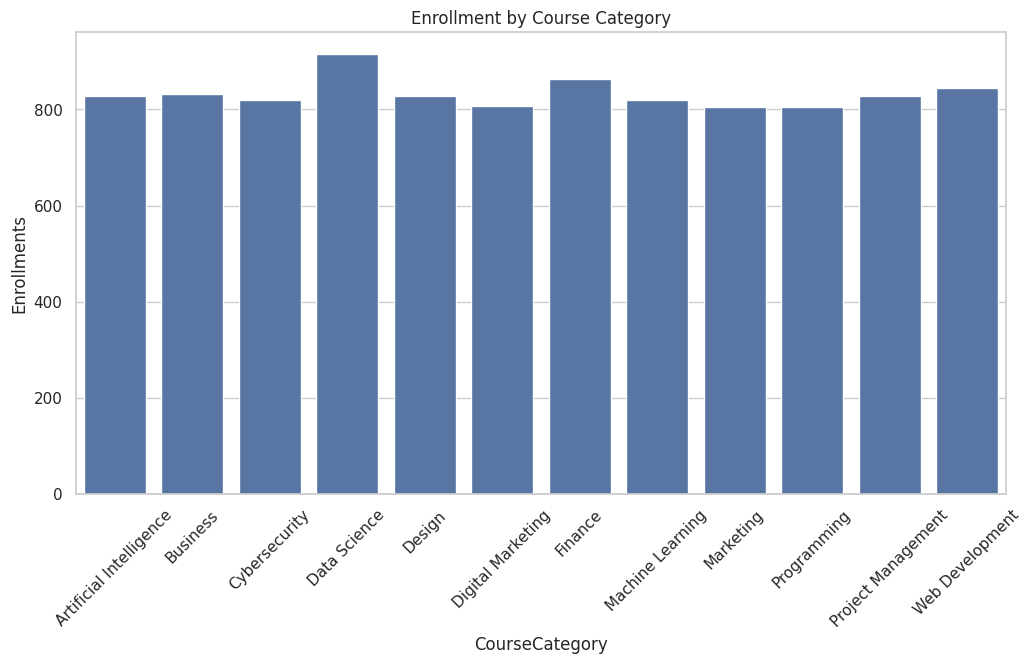

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_analysis,
    x="CourseCategory",
    y="Enrollments"
)

plt.xticks(rotation=45)

plt.title(
    "Enrollment by Course Category"
)

plt.show()

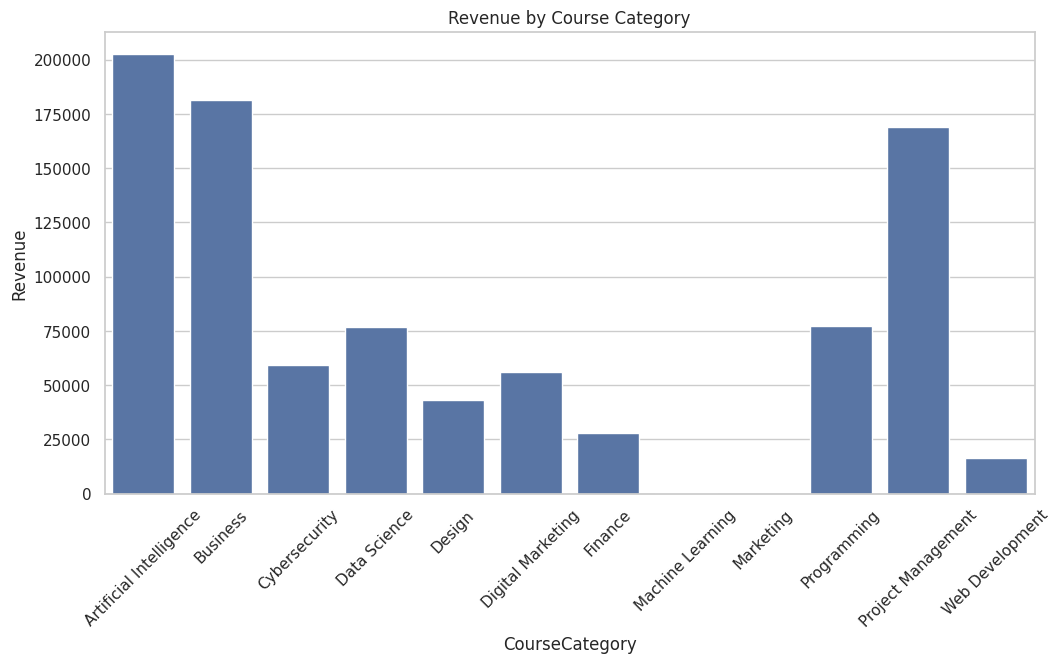

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_analysis,
    x="CourseCategory",
    y="Revenue"
)

plt.xticks(rotation=45)

plt.title(
    "Revenue by Course Category"
)

plt.show()

In [53]:
os.makedirs("models", exist_ok=True)

In [54]:
joblib.dump(
    best_enrollment_model,
    "models/enrollment_model.pkl"
)

['models/enrollment_model.pkl']

In [55]:
joblib.dump(
    best_revenue_model,
    "models/revenue_model.pkl"
)

['models/revenue_model.pkl']

In [56]:
metadata = {
    "features": features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "best_enrollment_model": best_enrollment_name,
    "best_revenue_model": best_revenue_name
}

joblib.dump(
    metadata,
    "models/model_metadata.pkl"
)

['models/model_metadata.pkl']

In [57]:
model_data.to_csv(
    "modeling_dataset.csv",
    index=False
)

category_analysis.to_csv(
    "category_analysis.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [58]:
from google.colab import files
import shutil

shutil.make_archive(
    "EduPro_Project",
    "zip",
    "."
)

files.download(
    "EduPro_Project.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
os.makedirs("app.py", exist_ok=True)

In [67]:
!git clone https://github.com/ajstyle12e/Edu-Pro-An.git

Cloning into 'Edu-Pro-An'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [68]:
%cd /content/Edu-Pro-An

!mkdir -p data notebooks models app

/content/Edu-Pro-An


In [69]:
!ls /content

 app.py				   'EduPro Online Platform.xlsx'   models
 category_analysis.csv		    EduPro_Project.zip		   sample_data
 Edu-Pro-An			    feature_importance.csv
'EduPro Online Platform (1).xlsx'   modeling_dataset.csv


In [74]:
!cp "EduPro2.ipynb" notebooks/predictive_modeling.ipynb

cp: cannot stat 'EduPro2.ipynb': No such file or directory
